In [ ]:
# final edition of correlation models from sklearn, on full data. take heavily from the init_corr_models files
# TODO

In [ ]:
# importing modules and packages 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error 
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
from sklearn.neural_network import MLPRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


In [ ]:
df = pd.read_csv('Daily_Means_Through_2022.csv')

In [ ]:
df

In [ ]:
print(df.dtypes)

# date to datetime (though we change it again after so idk if this is even smart)
df['Date'] = pd.to_datetime(df['date'])
df_pivot = df.pivot_table(index=['Date', 'site', 'depth'], columns='parameter', values='measure', aggfunc='mean')
df_pivot.reset_index(inplace=True)
df_pivot.drop(columns=['DO_pct'], inplace=True)
df_pivot = df_pivot[df_pivot["depth"] != "mid"]
df_pivot

In [ ]:
df_new = df_pivot.pivot_table(index=['Date', 'site'], 
                          columns='depth', 
                          values=['DO_mg/L', 'Density_g/cm3', 'Depth_m', 'Salinity_ppt', 'Temp_C', 'pH', 'Chl_ug/L', "Turb_NTU"])
df_new.columns = [f"{pos}_{col}" for col, pos in df_new.columns]

# Reset index to make it a regular dataframe
df_pivot = df_new.reset_index()

df_pivot

In [ ]:
# if a row has both bottom and surface density, add a column for the difference
df_pivot['stratification'] = df_pivot['bottom_Density_g/cm3'] - df_pivot['surface_Density_g/cm3']
df_pivot

In [ ]:
# one hot encoding depth, site
#df = pd.get_dummies(df_pivot, columns=['depth', 'site'], drop_first=True)
df = pd.get_dummies(df_pivot, columns=['site'], drop_first=True)
# turn date into a number
df['Date'] = df['Date'].map(pd.Timestamp.toordinal)

In [ ]:
# get nans
df.dropna(inplace=True, subset=["bottom_DO_mg/L", "surface_DO_mg/L"])
print(df.isna().sum())
print(len(df))

In [ ]:
lr = LinearRegression()
imp = IterativeImputer(estimator=lr, verbose=2, max_iter=10, tol=1e-10, imputation_order='roman')
ImputedData = imp.fit_transform(df)
ImputedData

In [ ]:
old_for_unscale = ImputedData
old_for_unscale = pd.DataFrame(old_for_unscale, columns=df.columns)
ImputedData = scaler.fit_transform(ImputedData)
ImputedData = pd.DataFrame(ImputedData, columns=df.columns)
ImputedData

In [ ]:
df = ImputedData

X = df.drop(columns=['bottom_DO_mg/L', 'surface_DO_mg/L'])
y = df['bottom_DO_mg/L']
y_surface = df['surface_DO_mg/L']

# train test split - test data is taken 
# X_train = X[X["Date"] < 738000]
# X_test = X[X["Date"] >= 738000]
# y_train = y[X["Date"] < 738000]
# y_test = y[X["Date"] >= 738000]
# y_surface_train = y_surface[X["Date"] < 738000]
# y_surface_test = y_surface[X["Date"] >= 738000]


# take the last 10% of the data as test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)
y_surface_train = y_surface[:len(X_train)]
y_surface_test = y_surface[len(X_train):]


print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
y_train


In [ ]:
# y.reset_index(drop=True, inplace=True)
# y_surface.reset_index(drop=True, inplace=True)
# y

In [ ]:
# random forest regressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Random Forest")
print("Test bottom")
# print(mean_squared_error(y_test, y_pred))
# print(mean_absolute_error(y_test, y_pred))
print(mean_absolute_percentage_error(y_test, y_pred))
print("Test surface")
rf.fit(X_train, y_surface_train)
y_surface_pred = rf.predict(X_test)
print(mean_absolute_percentage_error(y_surface_test, y_surface_pred))


In [ ]:
# cross validation
scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_mean_absolute_percentage_error')
print("Cross Validation")
print(scores)
print(np.mean(scores))

In [ ]:
et = ExtraTreesRegressor()
et.fit(X_train, y_train)
y_pred = et.predict(X_test)
print("Extra Trees")
print("Test bottom")
# print(mean_squared_error(y_test, y_pred))
# print(mean_absolute_error(y_test, y_pred))
print(mean_absolute_percentage_error(y_test, y_pred))
print("Test surface")
et.fit(X_train, y_surface_train)
y_surface_pred = et.predict(X_test)
print(mean_absolute_percentage_error(y_surface_test, y_surface_pred))

In [ ]:
# grid search for extra trees
param_grid = {
    #'bootstrap': [True],
    #'max_depth': [80, 90, 100, 110],
    'max_features': [1, 2, 4, 8, 16],
    #'min_samples_leaf': [3, 4, 5],
    #'min_samples_split': [2, 5, 10],
    #'n_estimators': [100, 500, 1000]
}
et = ExtraTreesRegressor()
grid_search = GridSearchCV(estimator = et, param_grid = param_grid, 
                          cv = 3, n_jobs = -1, verbose = True)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
best_grid = grid_search.best_estimator_
y_pred = best_grid.predict(X_test)
print("Extra Trees Grid Search")
print("Test")
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_absolute_percentage_error(y_test, y_pred))

In [ ]:
# cross validation
scores = cross_val_score(best_grid, X_train, y_train, cv=5, scoring='neg_mean_absolute_percentage_error')
print("Cross Validation")
print(scores)
print(np.mean(scores))

In [ ]:
et = HistGradientBoostingRegressor()
et.fit(X_train, y_train)
y_pred = et.predict(X_test)
print("Hist Gradient Boosting")
print("Test Bottom")
# print(mean_squared_error(y_test, y_pred))
# print(mean_absolute_error(y_test, y_pred))
print(mean_absolute_percentage_error(y_test, y_pred))
print("Test Surface")
et.fit(X_train, y_surface_train)
y_surface_pred = et.predict(X_test)
print(mean_absolute_percentage_error(y_surface_test, y_surface_pred))

In [ ]:
scores = cross_val_score(et, X_train, y_train, cv=5, scoring='neg_mean_absolute_percentage_error')
print("Cross Validation")
print(scores)
print(np.mean(scores))

In [ ]:
# grid search for extra trees
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_iter': [100, 200],
    'max_leaf_nodes': [10, 20, 30],
    'l2_regularization': [0.0, 0.1, 1.0]
}
et = HistGradientBoostingRegressor()
grid_search = GridSearchCV(estimator = et, param_grid = param_grid, 
                          cv = 3, n_jobs = -1, verbose = 10)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
best_grid = grid_search.best_estimator_
y_pred = best_grid.predict(X_test)
print("Extra Trees Grid Search")
print("Test")
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_absolute_percentage_error(y_test, y_pred))

In [ ]:
lr = LinearRegression()
imp = IterativeImputer(estimator=lr, verbose=2, max_iter=15, tol=1e-10, imputation_order='roman')
ImputedData = imp.fit_transform(X)
ImputedData

In [ ]:
ImputedData = pd.DataFrame(ImputedData, columns=X.columns)
ImputedData

In [ ]:
et = HistGradientBoostingRegressor()
et.fit(X_train, y_train)
y_pred = et.predict(X_test)
print("Hist Gradient Boosting")
print("Test")
print(mean_squared_error(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_absolute_percentage_error(y_test, y_pred))

In [ ]:
# mlp regressor
mlp = MLPRegressor(hidden_layer_sizes=[64, 64], max_iter=1000, verbose=True, early_stopping=True, activation='relu', learning_rate='constant', learning_rate_init=0.001)
#mlp.fit(X_train, y_train)
# y_pred = mlp.predict(X_test)
# print("MLP")
# print("Test")
# print(mean_squared_error(y_test, y_pred))
# print(mean_absolute_error(y_test, y_pred))
# print(mean_absolute_percentage_error(y_test, y_pred))
# print("Train")
# y_pred = mlp.predict(X_train)
# print(mean_squared_error(y_train, y_pred))
# print(mean_absolute_error(y_train, y_pred))
# print(mean_absolute_percentage_error(y_train, y_pred))


In [ ]:
def unscaled_mape(y, y_pred_scaled):
    scaler.fit(old_for_unscale["bottom_DO_mg/L"].values.reshape(-1, 1)) 
    unscaled_y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    #unscaled_y = scaler.inverse_transform(y.reshape(-1, 1)).flatten()
    y_df = pd.DataFrame(y)
    #print(y_df)
    unscaled_y = scaler.inverse_transform(y_df).flatten()
    return mean_absolute_percentage_error(unscaled_y, unscaled_y_pred)

In [ ]:
print("Test Bottom")
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
unscaled_mape(y_test, y_pred)

In [ ]:
print("Test Surface")
mlp.fit(X_train, y_surface_train)
y_surface_pred = mlp.predict(X_test)
unscaled_mape(y_surface_test, y_surface_pred)

In [ ]:
# cross validation
scores = cross_val_score(mlp, X, y, cv=5, scoring='neg_mean_absolute_percentage_error')
print("Cross Validation")
print(scores)
print(np.mean(scores))

In [ ]:
from sklearn.metrics import make_scorer
mape_scorer = make_scorer(unscaled_mape, greater_is_better=False)

In [ ]:
mape_scores = cross_val_score(mlp, X, y, cv=5, scoring=mape_scorer)

In [ ]:
print(f"Unscaled MAPE Scores: {-mape_scores}")  # Negative because scikit-learn minimizes the score
print(f"Mean MAPE: {-mape_scores.mean():.4f}%")

In [ ]:
y

In [ ]:
print(y_pred)
print(len(y_pred))

In [ ]:
scaler.fit(old_for_unscale["bottom_DO_mg/L"].values.reshape(-1, 1)) 
y_pred_original = scaler.inverse_transform(y_pred.reshape(-1, 1))

In [ ]:
y_pred_original

In [ ]:
print(mean_absolute_percentage_error(y_pred_original, old_for_unscale["bottom_DO_mg/L"][-len(y_pred_original):].values))

In [ ]:
#turn into a dataframe
old_for_unscale = pd.DataFrame(old_for_unscale, columns=df.columns)
old_for_unscale

In [ ]:
import shap

In [ ]:
# explain the model
sample = shap.kmeans(X_train, 100)
explainer = shap.KernelExplainer(mlp.predict, sample)

In [ ]:
sample_test = X_test.sample(100)
shap_values = explainer.shap_values(sample_test)
shap_values

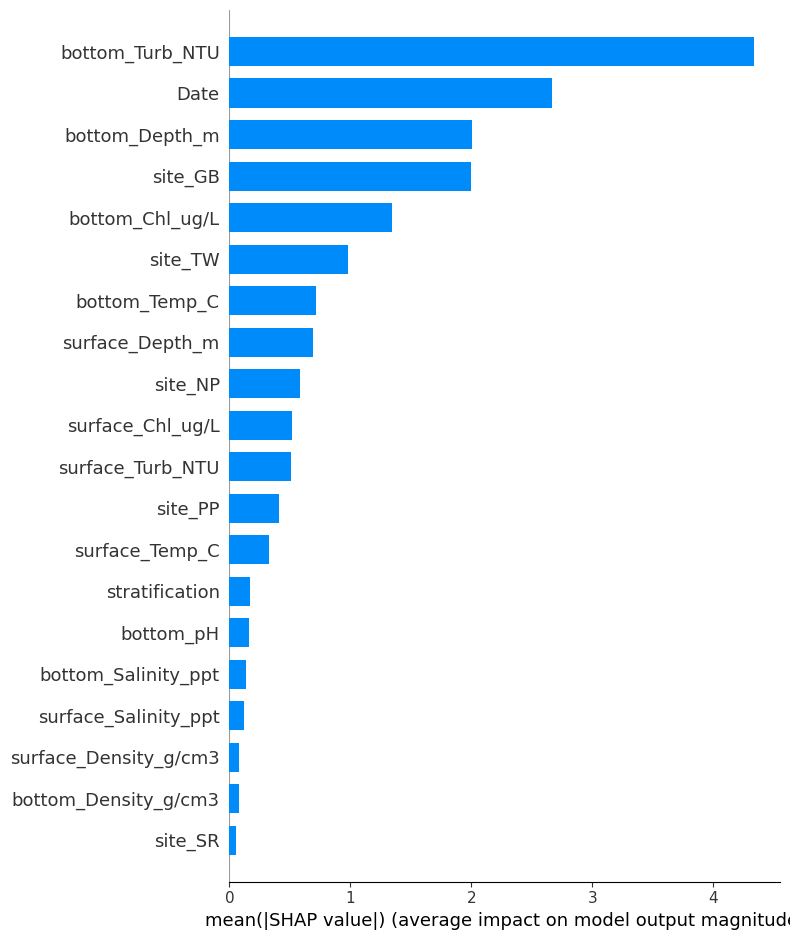

In [ ]:
# plot the SHAP values
shap.summary_plot(shap_values, sample_test, plot_type="bar")

In [ ]:
# heatmap of SHAP values
shap.plots.heatmap(shap_values)


In [ ]:
# save shap values to csv
shap_values_df = pd.DataFrame(shap_values, columns=sample_test.columns)
shap_values_df.to_csv('shap_values.csv', index=False)

In [ ]:
et

In [ ]:
X = old_for_unscale.drop(columns=['bottom_DO_mg/L', 'surface_DO_mg/L'])
y = old_for_unscale['bottom_DO_mg/L']
y_surface = old_for_unscale['surface_DO_mg/L']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)
y_surface_train = y_surface[:len(X_train)]
y_surface_test = y_surface[len(X_train):]
print(X_train)


In [ ]:
# test et
et = HistGradientBoostingRegressor()
et.fit(X_train, y_train)
y_pred = et.predict(X_test)
print("Hist Gradient Boosting")
print("Test")
print(mean_absolute_percentage_error(y_test, y_pred))

In [ ]:
et.fit(X_train, y_surface_train)
y_pred_surface = et.predict(X_test)
print("Test Surface")
print(mean_absolute_percentage_error(y_surface_test, y_pred_surface))

In [ ]:
# save the model
import pickle
with open('et_model.pkl', 'wb') as f:
    pickle.dump(et, f)
